In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [2]:
df = pd.read_parquet('/content/TOP250_STOCKS_6Y_FINAL.parquet')
df_AAPL = df[df["Ticker"] == "AAPL"]

In [3]:
df_AAPL.head()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,SMA_20,EMA_20,...,volatility_20d,index_adj_close,index_close,index_high,index_low,index_open,index_volume,index_return,index_volatility,fed_rate
1486,2020-04-14,AAPL,70.000000,72.062500,69.512497,71.762497,69.358711,194994800.0,63.113875,64.132639,...,0.043131,2846.060059,2846.060059,2851.850098,2805.100098,2805.100098,5615730000,0.030573,0.041409,0.05
1487,2020-04-15,AAPL,70.599998,71.582497,70.157501,71.107498,68.725655,131154400.0,63.508500,64.796912,...,0.042521,2783.360107,2783.360107,2801.879883,2761.540039,2795.639893,5208000000,-0.022030,0.040208,0.05
1488,2020-04-16,AAPL,71.845001,72.050003,70.587502,71.672501,69.271751,157125200.0,64.008750,65.451730,...,0.041881,2799.550049,2799.550049,2806.510010,2764.320068,2799.340088,5228810000,0.005817,0.037876,0.05
1489,2020-04-17,AAPL,71.172501,71.737503,69.214996,70.699997,68.331818,215250000.0,64.484000,65.951565,...,0.042021,2874.560059,2874.560059,2879.219971,2830.879883,2842.429932,5804810000,0.026794,0.038083,0.05
1490,2020-04-20,AAPL,69.487503,70.419998,69.212502,69.232498,66.913467,130015200.0,65.080124,66.264035,...,0.039182,2823.159912,2823.159912,2868.979980,2820.429932,2845.620117,5228630000,-0.017881,0.036618,0.05


In [4]:
# CONFIG
FEATURES = ["Close", "RSI_14", "Volume", "index_close", "fed_rate"]
LOOKBACK = 60
HORIZON = 1
TRAIN_RATIO = 0.95

KERNEL_SIZE = 15
EPOCHS = 40
BATCH_SIZE = 32

# 1) Prepare data
df = df_AAPL.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Target = next-day price change
df["target_diff"] = df["Close"].shift(-HORIZON) - df["Close"]

# We also need Close(t) to reconstruct Close(t+1)
df["close_t"] = df["Close"]

use_cols = ["Date"] + FEATURES + ["target_diff", "close_t"]
df = df[use_cols].dropna().reset_index(drop=True)

# 2) Time split
split_idx = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print("Train:", train_df["Date"].iloc[0], "→", train_df["Date"].iloc[-1], "| rows:", len(train_df))
print("Test :", test_df["Date"].iloc[0],  "→", test_df["Date"].iloc[-1],  "| rows:", len(test_df))

# 3) Scale X and y
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_raw = train_df[FEATURES].values.astype(np.float32)
X_test_raw  = test_df[FEATURES].values.astype(np.float32)

y_train_raw = train_df["target_diff"].values.reshape(-1, 1).astype(np.float32)
y_test_raw  = test_df["target_diff"].values.reshape(-1, 1).astype(np.float32)

X_train_scaled = X_scaler.fit_transform(X_train_raw)
X_test_scaled  = X_scaler.transform(X_test_raw)

y_train_scaled = y_scaler.fit_transform(y_train_raw).flatten()
y_test_scaled  = y_scaler.transform(y_test_raw).flatten()

# 4) Rolling windows
def make_windows(X, y, close_t, lookback):
    Xw, yw, ct = [], [], []
    for i in range(lookback - 1, len(X)):
        Xw.append(X[i - lookback + 1 : i + 1])
        yw.append(y[i])
        ct.append(close_t[i])
    return np.array(Xw, np.float32), np.array(yw, np.float32), np.array(ct, np.float32)

X_train, y_train, close_t_train = make_windows(
    X_train_scaled, y_train_scaled, train_df["close_t"].values, LOOKBACK
)

X_test, y_test, close_t_test = make_windows(
    X_test_scaled, y_test_scaled, test_df["close_t"].values, LOOKBACK
)

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

assert KERNEL_SIZE <= LOOKBACK

Train: 2020-04-14 00:00:00 → 2025-11-19 00:00:00 | rows: 1410
Test : 2025-11-20 00:00:00 → 2026-03-11 00:00:00 | rows: 75

Shapes:
X_train: (1351, 60, 5) y_train: (1351,)
X_test : (16, 60, 5) y_test : (16,)


In [7]:
tf.keras.backend.clear_session()

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATURES))),
    layers.Conv1D(32, kernel_size=KERNEL_SIZE, padding="causal", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"]
)

es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 1.0285 - mae: 0.7222 - val_loss: 1.2489 - val_mae: 0.7723
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0164 - mae: 0.7181 - val_loss: 1.2360 - val_mae: 0.7684
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0120 - mae: 0.7164 - val_loss: 1.2350 - val_mae: 0.7685
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.0141 - mae: 0.7175 - val_loss: 1.2039 - val_mae: 0.7614
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0141 - mae: 0.7140 - val_loss: 1.2170 - val_mae: 0.7652
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.0055 - mae: 0.7140 - val_loss: 1.2896 - val_mae: 0.7891
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.0015 - mae: 0.7131 - val_loss: 1.2213 - val_mae: 0.7679
Epoch 8/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.0001 - mae: 0.7112 - val_loss: 1.2505 - val_mae: 0.7776
Epoch 9/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.008

In [8]:
pred_diff_scaled = model.predict(X_test, verbose=0).flatten()
pred_diff = y_scaler.inverse_transform(pred_diff_scaled.reshape(-1, 1)).flatten()

actual_diff = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

pred_close_next = close_t_test + pred_diff
actual_close_next = close_t_test + actual_diff

In [12]:
mae_close = np.mean(np.abs(pred_close_next - actual_close_next))
rmse_close = np.sqrt(np.mean((pred_close_next - actual_close_next) ** 2))

print("MAE :", mae_close)
print("RMSE:", rmse_close)

baseline_pred = close_t_test
baseline_mae = np.mean(np.abs(baseline_pred - actual_close_next))
print("Baseline MAE:", baseline_mae)

MAE : 2.7247066
RMSE: 3.5048513
Baseline MAE: 2.7228165


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Dates aligned to X_test windows (window ends)
test_dates = test_df["Date"].values[LOOKBACK-1:]   # length = len(pred_close_next)

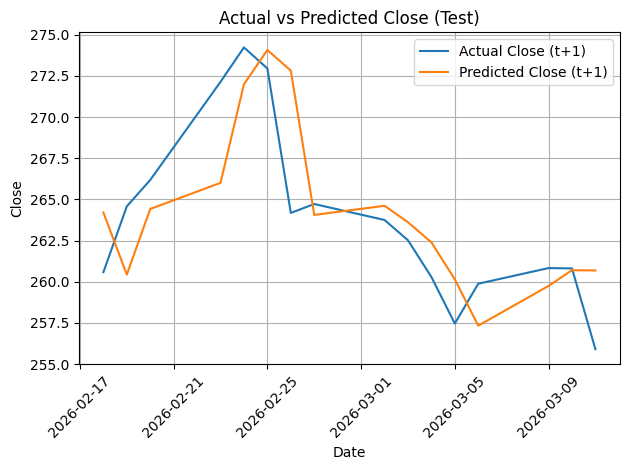

In [10]:
plt.figure()
plt.plot(test_dates, actual_close_next, label="Actual Close (t+1)")
plt.plot(test_dates, pred_close_next, label="Predicted Close (t+1)")
plt.title("Actual vs Predicted Close (Test)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

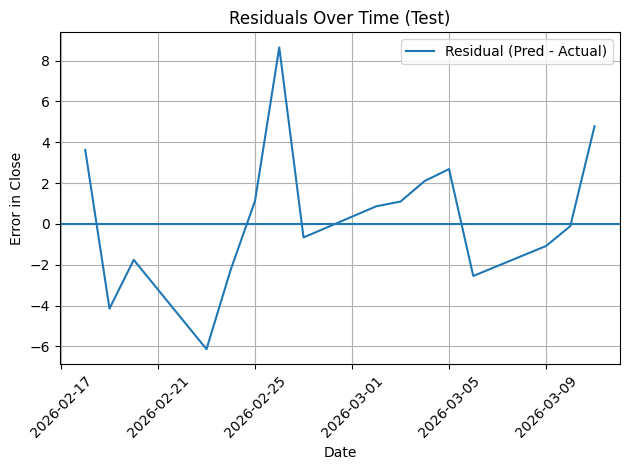

In [11]:
residuals = pred_close_next - actual_close_next

plt.figure()
plt.plot(test_dates, residuals, label="Residual (Pred - Actual)")
plt.axhline(0)
plt.title("Residuals Over Time (Test)")
plt.xlabel("Date")
plt.ylabel("Error in Close")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


np.random.seed(42)
tf.random.set_seed(42)


FEATURES = ["Open", "Close", "RSI_14", "Volume", "index_close", "fed_rate"]
LOOKBACK = 60
HORIZON = 1
TRAIN_RATIO = 0.90

EPOCHS = 60
BATCH_SIZE = 32


df = df_AAPL.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Better to compute target directly from Close
# target_diff(t) = Close(t+1) - Close(t)
df["target_diff"] = df["Close"].shift(-HORIZON) - df["Close"]

# Close(t) used later to reconstruct Close(t+1)
df["close_t"] = df["Close"]

# Optional: keep actual target date for reporting
df["target_date"] = df["Date"].shift(-HORIZON)

use_cols = ["Date", "target_date"] + FEATURES + ["target_diff", "close_t"]
df = df[use_cols].dropna().reset_index(drop=True)

print("Total rows after cleaning:", len(df))
print(df.head())


split_idx = int(len(df) * TRAIN_RATIO)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print("\nTrain:", train_df["Date"].iloc[0], "→", train_df["Date"].iloc[-1], "| rows:", len(train_df))
print("Test :", test_df["Date"].iloc[0],  "→", test_df["Date"].iloc[-1],  "| rows:", len(test_df))

# 3) Fit scalers on TRAIN only
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaler.fit(train_df[FEATURES].values.astype(np.float32))
y_scaler.fit(train_df[["target_diff"]].values.astype(np.float32))

# Scale ALL rows using train-fitted scalers
# This lets test windows use past context correctly without leakage
X_all_scaled = X_scaler.transform(df[FEATURES].values.astype(np.float32))
y_all_scaled = y_scaler.transform(df[["target_diff"]].values.astype(np.float32)).flatten()

close_all = df["close_t"].values.astype(np.float32)
target_dates_all = df["target_date"].values

# 4) Rolling windows
def make_windows(X, y, close_t, target_dates, lookback):
    Xw, yw, ct, td, end_idx_list = [], [], [], [], []

    for end_idx in range(lookback - 1, len(X)):
        start_idx = end_idx - lookback + 1
        Xw.append(X[start_idx:end_idx + 1])
        yw.append(y[end_idx])
        ct.append(close_t[end_idx])            # Close(t)
        td.append(target_dates[end_idx])       # date of Close(t+1)
        end_idx_list.append(end_idx)

    return (
        np.array(Xw, dtype=np.float32),
        np.array(yw, dtype=np.float32),
        np.array(ct, dtype=np.float32),
        np.array(td),
        np.array(end_idx_list)
    )

X_all, y_all, close_t_all, target_dates_w, end_idxs = make_windows(
    X_all_scaled, y_all_scaled, close_all, target_dates_all, LOOKBACK
)

# Train/test split on window END index
# If window ends before split_idx -> train
# If window ends at/after split_idx -> test
train_mask = end_idxs < split_idx
test_mask  = end_idxs >= split_idx

X_train_full = X_all[train_mask]
y_train_full = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]
close_t_test = close_t_all[test_mask]
target_dates_test = target_dates_w[test_mask]

print("\nWindowed shapes:")
print("X_train_full:", X_train_full.shape, "y_train_full:", y_train_full.shape)
print("X_test      :", X_test.shape,       "y_test      :", y_test.shape)


val_size = max(1, int(len(X_train_full) * 0.1))

X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]

X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]

print("\nFinal train/val/test:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)

tf.keras.backend.clear_session()

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATURES))),

    # CNN block for local temporal pattern extraction
    layers.Conv1D(filters=64, kernel_size=5, padding="causal", activation="relu"),
    layers.Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu"),
    layers.MaxPooling1D(pool_size=2),

    # LSTM block for sequential memory
    layers.LSTM(64, return_sequences=True, dropout=0.2),
    layers.LSTM(32, dropout=0.2),

    # Dense block
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    shuffle=False,   # very important for time series
    verbose=1
)


pred_diff_scaled = model.predict(X_test, verbose=0).flatten()
pred_diff = y_scaler.inverse_transform(pred_diff_scaled.reshape(-1, 1)).flatten()

actual_diff = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

pred_close_next = close_t_test + pred_diff
actual_close_next = close_t_test + actual_diff


mae_close = np.mean(np.abs(pred_close_next - actual_close_next))
rmse_close = np.sqrt(np.mean((pred_close_next - actual_close_next) ** 2))

print("\nTEST RESULTS (on reconstructed Close(t+1))")
print("MAE :", float(mae_close))
print("RMSE:", float(rmse_close))

# Naive baseline: tomorrow close = today close
baseline_pred = close_t_test
baseline_mae = np.mean(np.abs(baseline_pred - actual_close_next))
baseline_rmse = np.sqrt(np.mean((baseline_pred - actual_close_next) ** 2))

print("\nBASELINE RESULTS")
print("Baseline MAE :", float(baseline_mae))
print("Baseline RMSE:", float(baseline_rmse))


results = pd.DataFrame({
    "target_date": pd.to_datetime(target_dates_test),
    "pred_close_next": pred_close_next,
    "actual_close_next": actual_close_next,
    "abs_error": np.abs(pred_close_next - actual_close_next)
})

print("\nSample predictions vs actual:")
print(results.head(10))

Total rows after cleaning: 1485
        Date target_date       Open      Close     RSI_14       Volume  \
0 2020-04-14  2020-04-15  70.000000  71.762497  78.670715  194994800.0   
1 2020-04-15  2020-04-16  70.599998  71.107498  76.887635  131154400.0   
2 2020-04-16  2020-04-17  71.845001  71.672501  77.364228  157125200.0   
3 2020-04-17  2020-04-20  71.172501  70.699997  74.515978  215250000.0   
4 2020-04-20  2020-04-21  69.487503  69.232498  70.309460  130015200.0   

   index_close  fed_rate  target_diff    close_t  
0  2846.060059      0.05    -0.654999  71.762497  
1  2783.360107      0.05     0.565002  71.107498  
2  2799.550049      0.05    -0.972504  71.672501  
3  2874.560059      0.05    -1.467499  70.699997  
4  2823.159912      0.05    -2.139999  69.232498  

Train: 2020-04-14 00:00:00 → 2025-08-06 00:00:00 | rows: 1336
Test : 2025-08-07 00:00:00 → 2026-03-11 00:00:00 | rows: 149

Windowed shapes:
X_train_full: (1277, 60, 6) y_train_full: (1277,)
X_test      : (149, 60, 6

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,865 (237.75 KB)

 Trainable params: 60,865 (237.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.3527 - mae: 0.6931 - val_loss: 0.6902 - val_mae: 1.0433 - learning_rate: 0.0010
Epoch 2/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3493 - mae: 0.6896 - val_loss: 0.6875 - val_mae: 1.0411 - learning_rate: 0.0010
Epoch 3/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3504 - mae: 0.6902 - val_loss: 0.6894 - val_mae: 1.0416 - learning_rate: 0.0010
Epoch 4/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.3477 - mae: 0.6877 - val_loss: 0.6880 - val_mae: 1.0408 - learning_rate: 0.0010
Epoch 5/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.3509 - mae: 0.6914 - val_loss: 0.6886 - val_mae: 1.0416 - learning_rate: 0.0010
Epoch 6/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3419 - mae: 0.6792
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.3478 - mae: 0.6877 - val_loss: 0.6878 - val_mae: 1.0406 - learning_rate: 0.0010
Epoch 7/

In [7]:

pred_train_scaled = model.predict(X_train_full, verbose=0).flatten()
pred_train_diff = y_scaler.inverse_transform(pred_train_scaled.reshape(-1, 1)).flatten()
actual_train_diff = y_scaler.inverse_transform(y_train_full.reshape(-1, 1)).flatten()

# We need aligned close_t and dates for train windows
close_t_train = close_t_all[train_mask]
target_dates_train = target_dates_w[train_mask]

pred_close_train = close_t_train + pred_train_diff
actual_close_train = close_t_train + actual_train_diff

train_results = pd.DataFrame({
    "target_date": pd.to_datetime(target_dates_train),
    "pred_close_next": pred_close_train,
    "actual_close_next": actual_close_train
})

train_results["signed_error"] = train_results["pred_close_next"] - train_results["actual_close_next"]
train_results["abs_error"] = np.abs(train_results["signed_error"])



pred_test_scaled = model.predict(X_test, verbose=0).flatten()
pred_test_diff = y_scaler.inverse_transform(pred_test_scaled.reshape(-1, 1)).flatten()
actual_test_diff = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

pred_close_test = close_t_test + pred_test_diff
actual_close_test = close_t_test + actual_test_diff

test_results = pd.DataFrame({
    "target_date": pd.to_datetime(target_dates_test),
    "pred_close_next": pred_close_test,
    "actual_close_next": actual_close_test
})

test_results["signed_error"] = test_results["pred_close_next"] - test_results["actual_close_next"]
test_results["abs_error"] = np.abs(test_results["signed_error"])

In [8]:
import matplotlib.pyplot as plt

def plot_results(results_df, title_prefix="Data"):
    # Actual vs Predicted
    plt.figure(figsize=(14, 6))
    plt.plot(results_df["target_date"], results_df["actual_close_next"], label="Actual Close")
    plt.plot(results_df["target_date"], results_df["pred_close_next"], label="Predicted Close")
    plt.title(f"{title_prefix}: Actual vs Predicted Next-Day Close")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Signed Error
    plt.figure(figsize=(14, 5))
    plt.plot(results_df["target_date"], results_df["signed_error"], label="Signed Error")
    plt.axhline(0, linestyle="--")
    plt.title(f"{title_prefix}: Prediction Error (Predicted - Actual)")
    plt.xlabel("Date")
    plt.ylabel("Error")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Absolute Error
    plt.figure(figsize=(14, 5))
    plt.plot(results_df["target_date"], results_df["abs_error"], label="Absolute Error")
    plt.title(f"{title_prefix}: Absolute Error")
    plt.xlabel("Date")
    plt.ylabel("Absolute Error")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

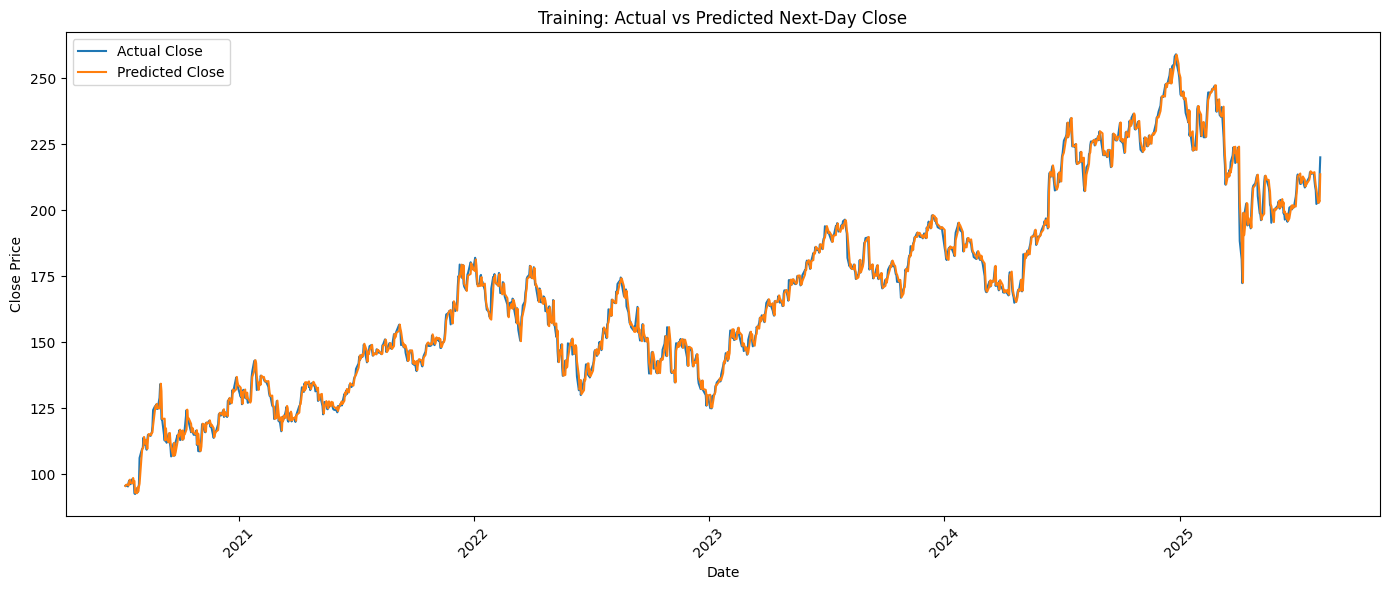

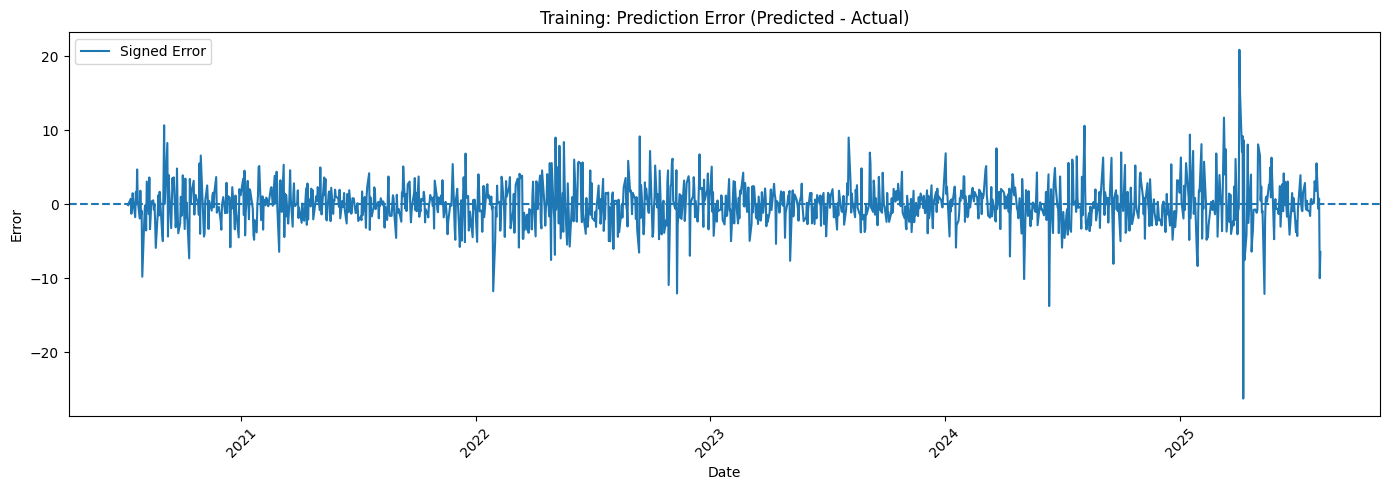

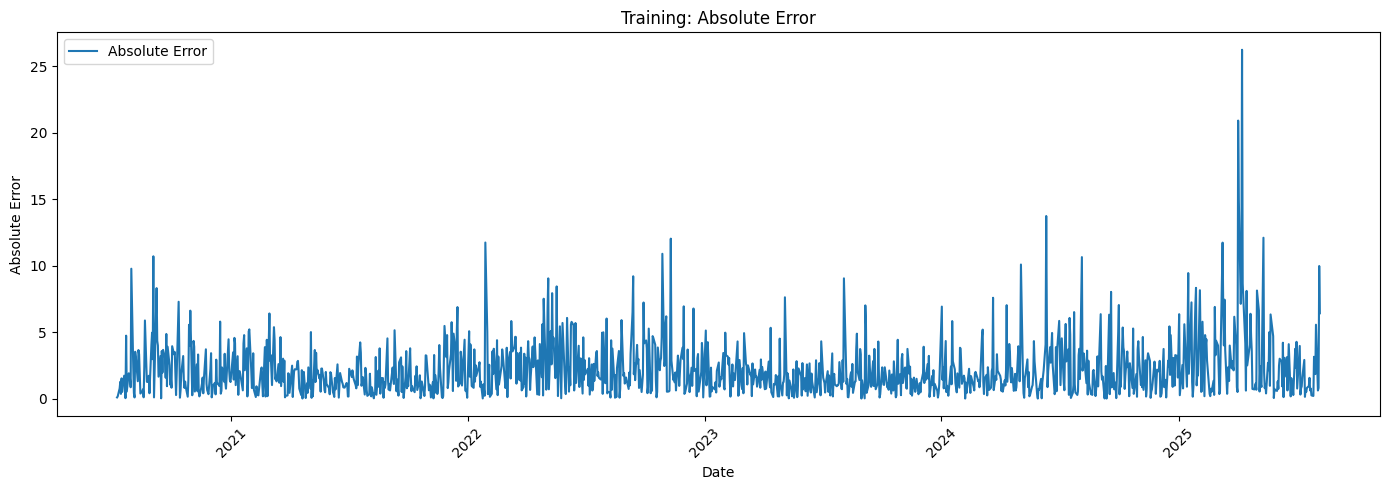

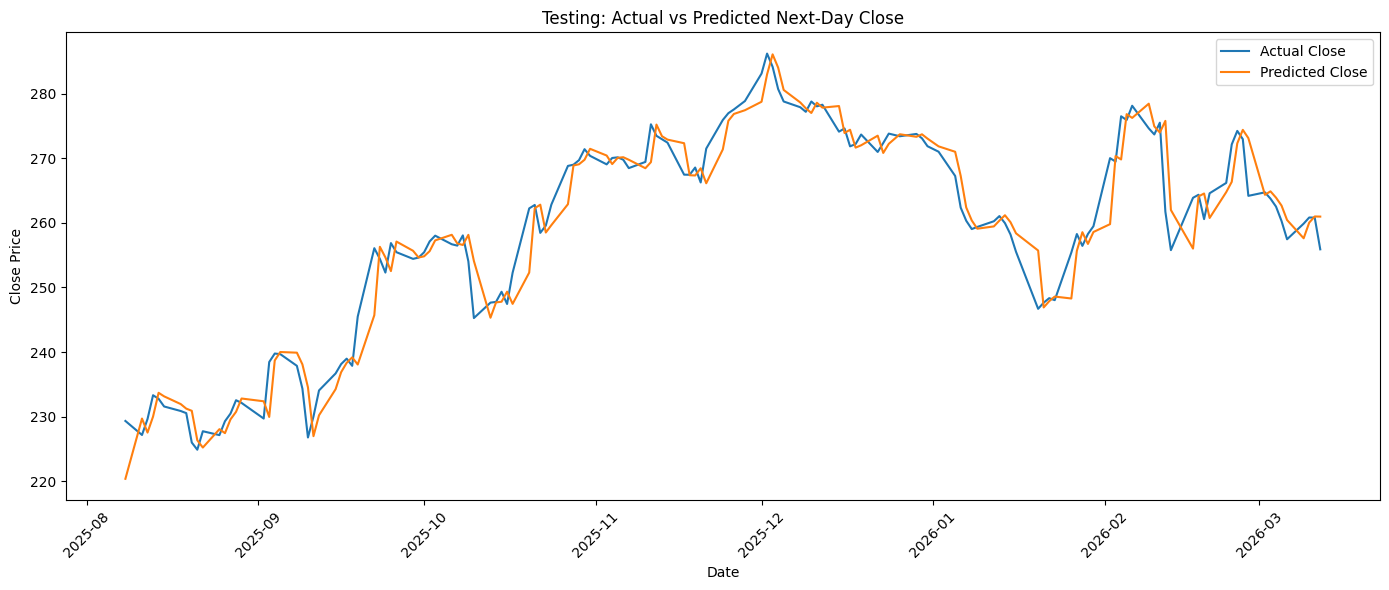

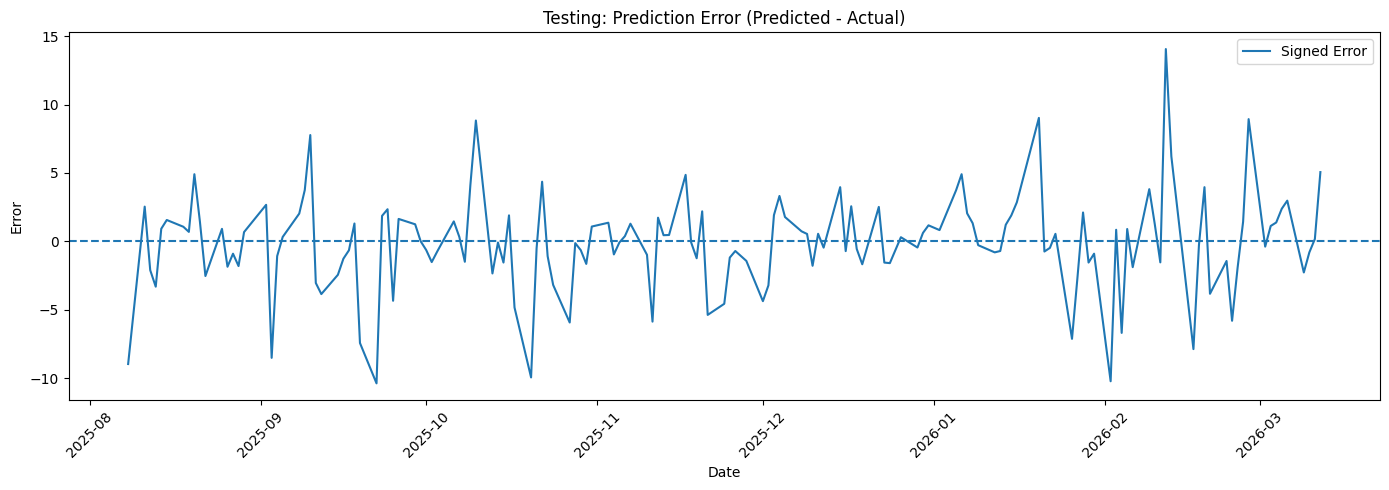

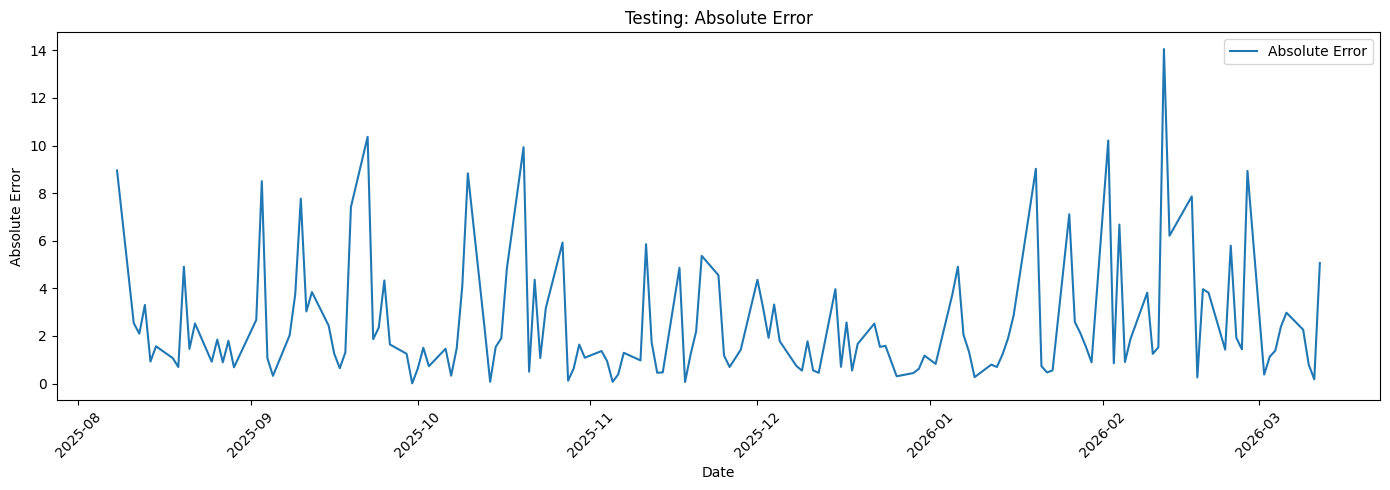

In [9]:
plot_results(train_results, title_prefix="Training")
plot_results(test_results, title_prefix="Testing")